# Section 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from prophet import Prophet

plt.style.use("ggplot")

# Section 2 — Load Dataset

In [2]:
subscriptions = pd.read_csv(
    "subscriptions_clean.csv"
)

subscriptions.head()

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,tenure_days
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,0,0,0,1,monthly,1,111
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,0,0,0,0,monthly,1,749
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,1,1,0,0,annual,0,582
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,0,0,0,1,monthly,1,20
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,0,0,0,0,monthly,1,902


# Section 3 — Convert Dates

In [3]:
subscriptions['start_date'] = pd.to_datetime(
    subscriptions['start_date']
)

subscriptions['end_date'] = pd.to_datetime(
    subscriptions['end_date']
)

subscriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   subscription_id    5000 non-null   object        
 1   account_id         5000 non-null   object        
 2   start_date         5000 non-null   datetime64[ns]
 3   end_date           486 non-null    datetime64[ns]
 4   plan_tier          5000 non-null   object        
 5   seats              5000 non-null   int64         
 6   mrr_amount         5000 non-null   int64         
 7   arr_amount         5000 non-null   int64         
 8   is_trial           5000 non-null   int64         
 9   upgrade_flag       5000 non-null   int64         
 10  downgrade_flag     5000 non-null   int64         
 11  churn_flag         5000 non-null   int64         
 12  billing_frequency  5000 non-null   object        
 13  auto_renew_flag    5000 non-null   int64         
 14  tenure_d

# Section 4 — Daily Revenue Aggregation

In [4]:
monthly_mrr = (
    subscriptions
    .groupby('start_date')['mrr_amount']
    .sum()
    .reset_index()
)

monthly_mrr.columns = [
    'ds',
    'y'
]

monthly_mrr.head()

,ds,y
0,2023-01-09,171
1,2023-01-12,931
2,2023-01-28,3582
3,2023-02-05,343
4,2023-02-06,1813


### Check Dataset Shape

In [5]:
monthly_mrr.shape

(625, 2)

There are 625 daily revenue observations available for forecasting.

# Section 5 — Revenue Trend

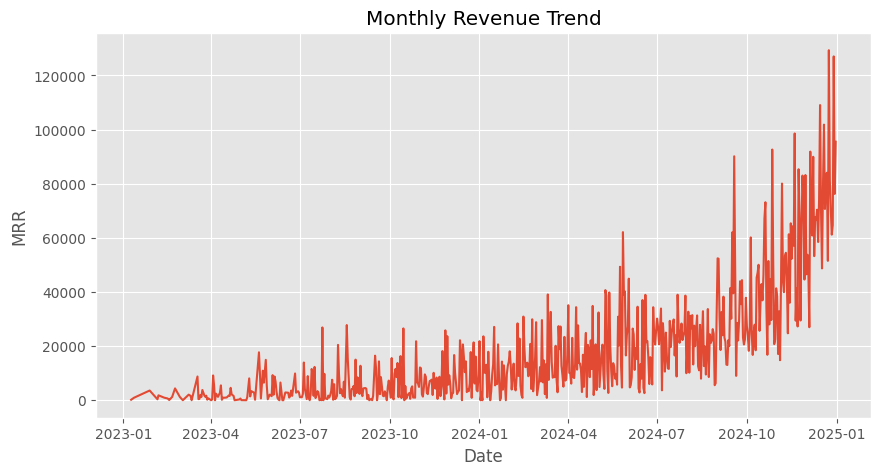

In [6]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_mrr['ds'],
    monthly_mrr['y']
)

plt.title(
    "Monthly Revenue Trend"
)

plt.xlabel("Date")

plt.ylabel("MRR")

plt.show()

# Section 6 — Monthly Resampling

In [7]:
monthly_forecast = (
    monthly_mrr
    .set_index('ds')
    .resample('ME')
    .sum()
    .reset_index()
)

monthly_forecast.head()

,ds,y
0,2023-01-31,4684
1,2023-02-28,11079
2,2023-03-31,25885
3,2023-04-30,41788
4,2023-05-31,85919


In [8]:
monthly_forecast.shape

(24, 2)

# Section 7 — Monthly Revenue Visualization

### Visualize Monthly Revenue

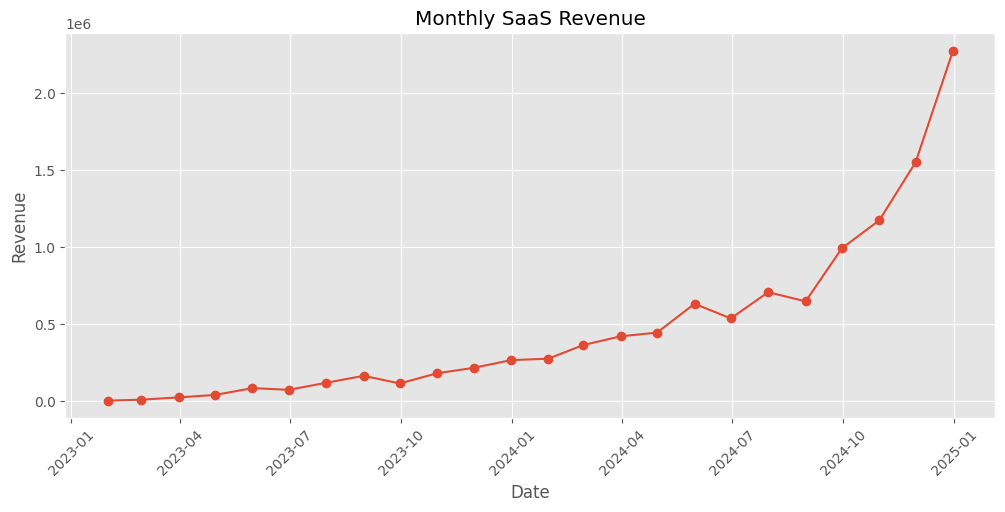

In [9]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_forecast['ds'],
    monthly_forecast['y'],
    marker='o'
)

plt.title(
    "Monthly SaaS Revenue"
)

plt.xlabel("Date")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

# Section 8 — Prophet Model

### Train Prophet Model

In [10]:
model = Prophet()

model.fit(monthly_forecast)

21:11:59 - cmdstanpy - INFO - Chain [1] start processing
21:12:00 - cmdstanpy - INFO - Chain [1] done processing


# Section 9 — Create Future Dates

## Generate Future Months

In [11]:
future = model.make_future_dataframe(
    periods=6,
    freq='ME'
)

future.tail()

,ds
25,2025-02-28
26,2025-03-31
27,2025-04-30
28,2025-05-31
29,2025-06-30


# Section 10 — Revenue Forecast

### Predict Future Revenue

In [12]:
forecast = model.predict(future)

forecast[
    ['ds',
     'yhat',
     'yhat_lower',
     'yhat_upper']
].tail(10)

,ds,yhat,yhat_lower,yhat_upper
20,2024-09-30,1.035008e+06,6.631660e+05,1.373344e+06
21,2024-10-31,1.102068e+06,7.099443e+05,1.478559e+06
22,2024-11-30,1.166965e+06,7.893191e+05,1.540386e+06
23,2024-12-31,1.234025e+06,8.599192e+05,1.604861e+06
24,2025-01-31,1.301085e+06,9.204842e+05,1.686721e+06
25,2025-02-28,1.361656e+06,9.643977e+05,1.743452e+06
26,2025-03-31,1.428716e+06,1.040072e+06,1.788453e+06
27,2025-04-30,1.493613e+06,1.151275e+06,1.868847e+06
28,2025-05-31,1.560673e+06,1.199269e+06,1.950496e+06
29,2025-06-30,1.625570e+06,1.235431e+06,1.998662e+06


### Forecast Summary

In [14]:
future_only = forecast[
    forecast['ds'] > monthly_forecast['ds'].max()
]

print("6-Month Revenue Forecast:\n")

print(
    future_only[
        ['ds','yhat','yhat_lower','yhat_upper']
    ].to_string(index=False)
)

print(
    "\nAverage Forecast Revenue:",
    round(future_only['yhat'].mean(),2)
)

print(
    "Total Forecast Revenue:",
    round(future_only['yhat'].sum(),2)
)

6-Month Revenue Forecast:

        ds         yhat   yhat_lower   yhat_upper
2025-01-31 1.301085e+06 9.204842e+05 1.686721e+06
2025-02-28 1.361656e+06 9.643977e+05 1.743452e+06
2025-03-31 1.428716e+06 1.040072e+06 1.788453e+06
2025-04-30 1.493613e+06 1.151275e+06 1.868847e+06
2025-05-31 1.560673e+06 1.199269e+06 1.950496e+06
2025-06-30 1.625570e+06 1.235431e+06 1.998662e+06

Average Forecast Revenue: 1461885.38
Total Forecast Revenue: 8771312.29


# Section 11 — Forecast Visualization

### Forecast Chart

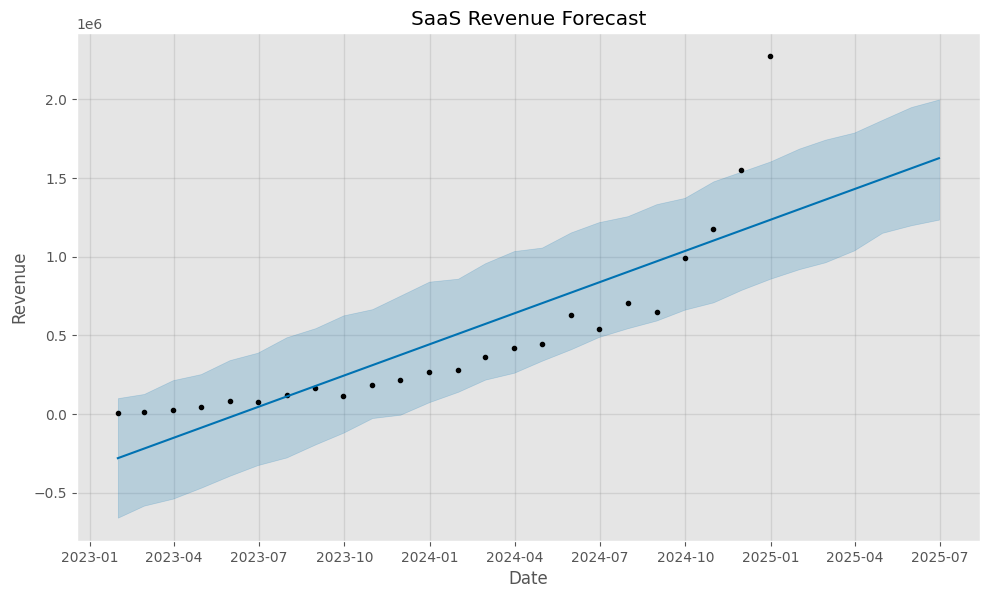

In [15]:
fig = model.plot(forecast)

plt.title(
    "SaaS Revenue Forecast"
)

plt.xlabel("Date")

plt.ylabel("Revenue")

plt.show()

# Section 12 — Forecast Components

### Trend Analysis

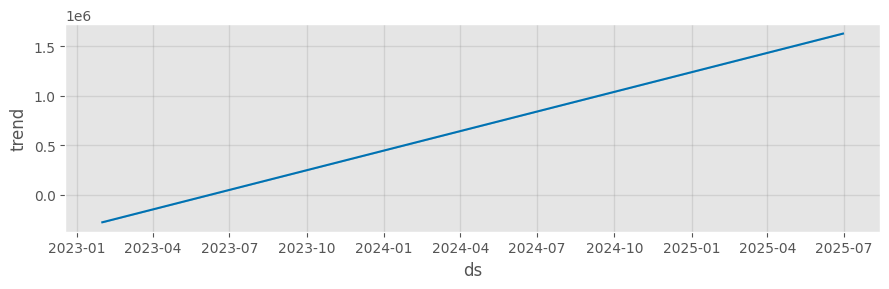

In [16]:
model.plot_components(
    forecast
)

plt.show()

# Section 13 — Export Forecast

In [17]:
forecast[
    [
        'ds',
        'yhat',
        'yhat_lower',
        'yhat_upper'
    ]
].to_csv(
    'revenue_forecast.csv',
    index=False
)

### Save Prophet model

In [18]:
import joblib

joblib.dump(
    model,
    'prophet_model.pkl'
)

print("Forecast exported successfully.")
print("Prophet model saved successfully.")

Forecast exported successfully.
Prophet model saved successfully.


# Section 14 — Business Insights

Insight 1 — Revenue Growth

Historical subscription revenue demonstrates a strong upward growth trend over time.

Insight 2 — Future Revenue Expansion

The Prophet model predicts continued revenue growth during the next six months.

Insight 3 — Forecasted Revenue

The average forecasted monthly MRR for the next six months is approximately $1.46 million, indicating sustained revenue growth.

Insight 4 — Business Expansion Potential

The increasing revenue trend suggests successful customer acquisition and subscription growth.

Insight 5 — Strategic Planning

Forecasted revenue can support budgeting, hiring decisions, pricing strategies, and future investment planning.

Insight 6 — Revenue Outlook

The total expected revenue over the next six months is approximately $8.77 million, supporting future business expansion initiatives.